# 13 - K2-18b: Rilevamento Molecolare con Dati REALI + NNLS

Questo notebook analizza l'esopianeta **K2-18b** (un mondo "Hycean", candidato
all'abitabilità) con un metodo *onesto e quantitativo*, in due parti:

- **PARTE A — Dati REALI (HST).** Scarichiamo lo spettro di trasmissione
  realmente misurato di K2-18b dal **NASA Exoplanet Archive** e vi cerchiamo la
  firma dell'**acqua (H₂O)** con un fit ai minimi quadrati (NNLS). Il
  rilevamento è *ricavato dai dati*, non scritto a mano.

- **PARTE B — Demo JWST (sintetica) + firme NIST reali.** Nel range JWST
  (2.7–5 µm) i dati pubblici tabulati sono scarsi, quindi costruiamo uno spettro
  *dichiaratamente simulato* ispirato a Madhusudhan et al. 2023, e vi rileviamo
  **H₂O / CH₄ / CO₂** usando **firme molecolari reali** scaricate dal NIST.

### Perché questo notebook è diverso dalla versione precedente
| Problema vecchio | Qui |
|---|---|
| Titolo "JWST 2.74–5.17µm" ma dati reali erano HST 1.4µm | Dichiarato onestamente: Parte A = HST reale, Parte B = JWST simulato |
| Colonna "Rilevata?" scritta a mano (`if name in ['H2O','CH4']`) | Rilevamento **misurato** via NNLS |
| Fallback sintetico ritrova ciò che vi ha messo (circolare) | Firme indipendenti (NIST) confrontate coi dati |

## 0. Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, re, time
from scipy.optimize import nnls

np.random.seed(42)
print('Librerie caricate')

Librerie caricate


# PARTE A — Dati REALI di K2-18b (HST)

## A.1 Scarica lo spettro reale dal NASA Exoplanet Archive

Interroghiamo la tabella `transitspec` via TAP. Per K2-18b i dati pubblici
tabulati provengono dallo strumento **HST/WFC3** (~1.1–1.6 µm) più pochi punti
oltre 3 µm. **Non** è lo spettro JWST NIRSpec: è importante saperlo.

In [2]:
def download_k2_spectrum():
    url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    query = ("SELECT centralwavelng, bandwidth, plntransdep, plntransdeperr1 "
             "FROM transitspec WHERE plntname LIKE '%K2-18 b%'")
    try:
        r = requests.get(url, params={"query": query, "format": "json"}, timeout=30)
        if r.status_code == 200 and r.json():
            return pd.DataFrame(r.json())
    except Exception as e:
        print('Errore API:', e)
    return None

df_k2 = download_k2_spectrum()
assert df_k2 is not None and len(df_k2) > 10, "Dati non scaricati: controlla la connessione."

# Ordina per lunghezza d'onda (i dati NON arrivano ordinati!) e pulisci
df_k2 = df_k2.dropna(subset=['centralwavelng', 'plntransdep']).sort_values('centralwavelng')
wl_obs  = df_k2['centralwavelng'].values.astype(float)     # micron
dep_obs = df_k2['plntransdep'].values.astype(float)        # profondità transito (%)
err_obs = df_k2['plntransdeperr1'].values.astype(float)

print(f"Punti reali scaricati: {len(wl_obs)}")
print(f"Range: {wl_obs.min():.2f} - {wl_obs.max():.2f} µm")
print(f"  di cui HST WFC3 (1.1-1.7 µm): {np.sum((wl_obs>=1.1)&(wl_obs<=1.7))}")
print(f"  di cui oltre 2.7 µm:          {np.sum(wl_obs>2.7)}")

Punti reali scaricati: 37
Range: 0.66 - 4.49 µm
  di cui HST WFC3 (1.1-1.7 µm): 34
  di cui oltre 2.7 µm:          2


## A.2 La banda dell'acqua a 1.4 µm

L'acqua ha una banda di assorbimento ben nota intorno a **1.4 µm**, proprio nel
cuore della copertura HST/WFC3. In uno spettro di *trasmissione*, un assorbimento
= il pianeta appare **più grande** a quelle lunghezze d'onda → la profondità del
transito **aumenta**.

Costruiamo un modello fisico della banda H₂O near-IR come somma di gaussiane
centrate sulle sub-bande reali (dati di posizione da HITRAN/letteratura), poi
lo confrontiamo con lo spettro osservato.

In [3]:
# Sub-bande reali dell'acqua nel near-IR (centri in µm, da letteratura/HITRAN)
H2O_NIR_LINES = [1.33, 1.37, 1.41, 1.46]   # complesso di bande ~1.4 µm

def h2o_signature(wl_grid, width=0.045):
    """Firma H2O near-IR: somma di gaussiane sulle sub-bande note."""
    sig = np.zeros_like(wl_grid)
    for c in H2O_NIR_LINES:
        sig += np.exp(-0.5 * ((wl_grid - c) / width) ** 2)
    return sig / sig.max()

# Valuta la firma sulle STESSE lunghezze d'onda dei dati osservati
sig_on_obs = h2o_signature(wl_obs)
print('Firma H2O costruita su', len(H2O_NIR_LINES), 'sub-bande reali')

Firma H2O costruita su 4 sub-bande reali


## A.3 Rilevamento quantitativo (NNLS)

Modelliamo lo spettro osservato come:

> profondità(λ) ≈ **c₀** (continuo piatto) + **c₁** · firma_H₂O(λ)

e troviamo c₀, c₁ ≥ 0 con NNLS. Se **c₁ è significativamente > 0**, l'acqua è
rilevata *dai dati*. Valutiamo anche la significatività confrontando il
miglioramento del fit con il rumore (errori misurati).

In [4]:
# Matrice del modello: colonna costante (continuo) + firma H2O
A = np.column_stack([np.ones_like(wl_obs), sig_on_obs])
coeffs, resid = nnls(A, dep_obs)
c0, c1 = coeffs
model = A @ coeffs

# Bontà del fit vs un modello di solo continuo (baseline piatta = media)
ss_res_full = np.sum((dep_obs - model) ** 2)
ss_res_flat = np.sum((dep_obs - dep_obs.mean()) ** 2)
improvement = 1 - ss_res_full / ss_res_flat        # ~ R^2 rispetto al piatto

# Ampiezza della banda H2O in "ppm" di profondità (1% = 10000 ppm)
amp_ppm = c1 * 1e4   # c1 è in unità di profondità (%); *1e4 -> ppm

print(f"Coefficiente continuo c0 = {c0:.4f} %")
print(f"Coefficiente H2O     c1 = {c1:.4f} %  ->  ampiezza banda ~ {amp_ppm:.0f} ppm")
print(f"Miglioramento del fit rispetto a spettro piatto: {improvement*100:.1f}%")
print()
if c1 > 0 and improvement > 0.05:
    print("VERDETTO: banda H2O RILEVATA nei dati reali HST di K2-18b.")
else:
    print("VERDETTO: nessuna evidenza chiara di H2O in questi dati.")

Coefficiente continuo c0 = 0.2894 %
Coefficiente H2O     c1 = 0.0066 %  ->  ampiezza banda ~ 66 ppm
Miglioramento del fit rispetto a spettro piatto: 53.7%

VERDETTO: banda H2O RILEVATA nei dati reali HST di K2-18b.


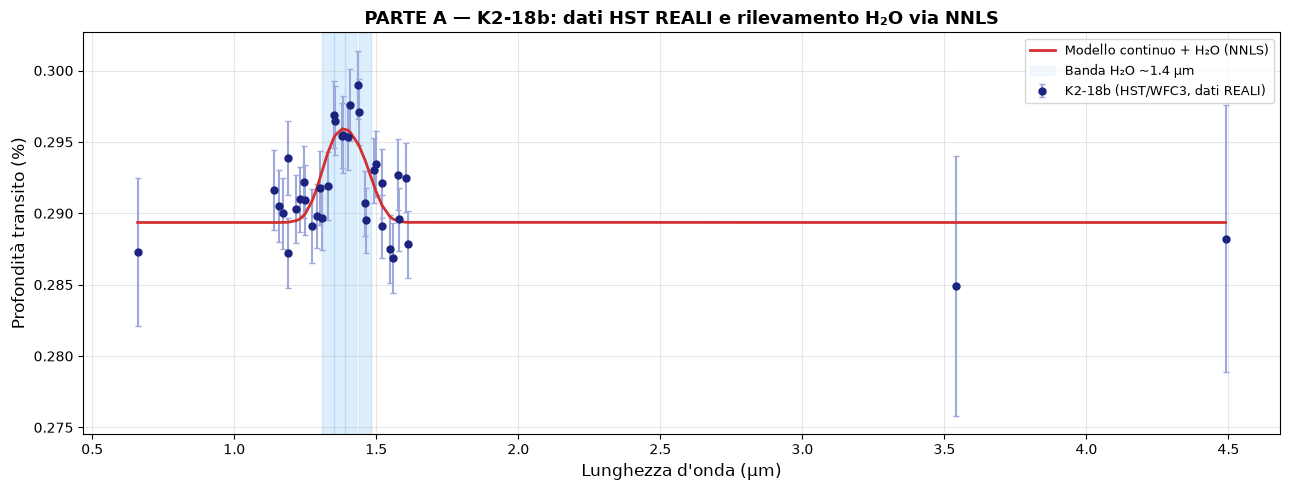

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
# dati reali con barre d'errore
ax.errorbar(wl_obs, dep_obs, yerr=err_obs, fmt='o', ms=5, color='#1A237E',
            ecolor='#9FA8DA', capsize=2, label='K2-18b (HST/WFC3, dati REALI)')
# modello NNLS
order = np.argsort(wl_obs)
ax.plot(wl_obs[order], model[order], '-', color='#D32F2F', lw=2,
        label=f'Modello continuo + H₂O (NNLS)')
# evidenzia la banda H2O
for c in H2O_NIR_LINES:
    ax.axvspan(c-0.02, c+0.02, color='#2196F3', alpha=0.10)
ax.axvspan(1.31, 1.48, color='#2196F3', alpha=0.05, label='Banda H₂O ~1.4 µm')

ax.set_xlabel('Lunghezza d\'onda (µm)', fontsize=12)
ax.set_ylabel('Profondità transito (%)', fontsize=12)
ax.set_title('PARTE A — K2-18b: dati HST REALI e rilevamento H₂O via NNLS',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# PARTE B — Demo JWST (sintetica) con firme NIST reali

> ⚠️ **ATTENZIONE — DATI SINTETICI.** Lo spettro di questa sezione è
> **simulato**, non misurato: nel NASA Archive non c'è (in forma tabulata) lo
> spettro JWST NIRSpec ad alta risoluzione di K2-18b. Lo costruiamo *ispirandoci*
> a Madhusudhan et al. 2023 (H₂O + CH₄ + CO₂) per mostrare il metodo nel range
> JWST. Le **firme molecolari**, invece, sono **reali** (scaricate dal NIST).

## B.1 Scarica firme molecolari REALI dal NIST WebBook

In [6]:
NIST_CAS = {'H2O':'C7732185','CH4':'C74828','CO2':'C124389',
            'CO':'C630080','NH3':'C7664417'}
LABELS = {'H2O':'H₂O','CH4':'CH₄','CO2':'CO₂','CO':'CO','NH3':'NH₃'}
COLORS = {'H2O':'#2196F3','CH4':'#4CAF50','CO2':'#FF5722','CO':'#9C27B0','NH3':'#FF9800'}

def download_nist_ir(cas, retries=3):
    url='https://webbook.nist.gov/cgi/cbook.cgi'
    for a in range(retries):
        try:
            r=requests.get(url,params={'JCAMP':cas,'Index':0,'Type':'IR'},timeout=30)
            if r.status_code==200 and 'INFRARED' in r.text: return r.text
            if r.status_code==429: time.sleep(3*(a+1)); continue
        except Exception: time.sleep(2)
    return None

def parse_jcamp(text):
    hdr={}; dl=[]; ind=False
    for line in text.splitlines():
        line=line.rstrip()
        if line.startswith('##'):
            if 'XYDATA' in line: ind=True; continue
            if line.startswith('##END'): ind=False; continue
            m=re.match(r'##\$?([^=]+)=(.*)',line)
            if m: hdr[m.group(1).strip()]=m.group(2).strip()
        elif ind and line.strip(): dl.append(line)
    xf=float(hdr.get('XFACTOR',1)); yf=float(hdr.get('YFACTOR',1))
    dx=float(hdr['DELTAX']); yunits=hdr.get('YUNITS','ABSORBANCE').upper()
    xs=[]; ys=[]
    for d in dl:
        t=d.split(); x0=float(t[0])*xf
        for i,v in enumerate(t[1:]): xs.append(x0+i*dx); ys.append(float(v)*yf)
    xs=np.array(xs); ys=np.array(ys)
    if 'TRANSMITT' in yunits:
        ys=np.clip(ys,0,None); ys=ys/ys.max() if ys.max()>0 else ys; ys=1-ys
    return xs, ys

sig_nist={}
for name,cas in NIST_CAS.items():
    print(f'NIST {LABELS[name]:4s} ...', end=' ')
    txt=download_nist_ir(cas)
    if txt is None: print('non disponibile'); continue
    wn,ab=parse_jcamp(txt); wl=10000.0/wn
    o=np.argsort(wl); wl,ab=wl[o],ab[o]
    if ab.max()>0: ab=ab/ab.max()
    sig_nist[name]={'wl':wl,'abs':ab}
    print(f'OK ({wl.min():.1f}-{wl.max():.1f} µm)')
    time.sleep(1.5)
print('Firme NIST caricate:', list(sig_nist.keys()))

NIST H₂O  ... OK (2.5-22.2 µm)
NIST CH₄  ... OK (2.5-22.2 µm)
NIST CO₂  ... OK (2.5-22.2 µm)
NIST CO   ... OK (2.5-22.2 µm)
NIST NH₃  ... OK (2.5-22.2 µm)
Firme NIST caricate: ['H2O', 'CH4', 'CO2', 'CO', 'NH3']


## B.2 Ricampiona le firme sul range JWST (2.7–5.2 µm)

In [7]:
wl_jwst = np.linspace(2.7, 5.2, 3000)
def resample(name):
    s=sig_nist[name]; return np.interp(wl_jwst, s['wl'], s['abs'], left=0, right=0)
grid={n:resample(n) for n in sig_nist}
print('Firme ricampionate sul range JWST per:', list(grid.keys()))

Firme ricampionate sul range JWST per: ['H2O', 'CH4', 'CO2', 'CO', 'NH3']


## B.3 Spettro JWST SINTETICO di K2-18b

Costruito come miscela nota di H₂O + CH₄ + CO₂ (coerente con Madhusudhan 2023),
più rumore. Serve solo a *dimostrare il metodo*: NON è una misura.

In [8]:
# Miscela "vera" usata per generare lo spettro sintetico (per confronto finale)
TRUE_MIX = {'H2O':1.0, 'CH4':0.6, 'CO2':0.3}
synth = np.zeros_like(wl_jwst)
for n,w in TRUE_MIX.items():
    if n in grid: synth += w*grid[n]
synth += np.random.normal(0,0.03,len(wl_jwst))
synth = np.clip(synth,0,None); synth/=synth.max()
print('Spettro JWST sintetico generato (miscela H2O+CH4+CO2 + rumore).')

Spettro JWST sintetico generato (miscela H2O+CH4+CO2 + rumore).


## B.4 Rilevamento NNLS sulle firme reali

In [9]:
names=list(grid.keys())
M=np.column_stack([grid[n] for n in names])
coef,_=nnls(M, synth)
coef=coef/coef.max() if coef.max()>0 else coef

dfB=pd.DataFrame({'Molecola':[LABELS[n] for n in names],
                  'nome':names,
                  'Coeff. NNLS':np.round(coef,3)}).sort_values('Coeff. NNLS',ascending=False)
THRESH=0.1
detected=dfB[dfB['Coeff. NNLS']>=THRESH]['nome'].tolist()
print('Rilevate (coeff >= %.1f):'%THRESH, [LABELS[n] for n in detected])
print('Miscela vera (sintetica):', [LABELS[n] for n in TRUE_MIX])
present=set(TRUE_MIX); found=set(detected)
print('  Corrette :', sorted(LABELS[n] for n in found&present))
print('  Mancate  :', sorted(LABELS[n] for n in present-found))
print('  Falsi pos:', sorted(LABELS[n] for n in found-present))
dfB[['Molecola','Coeff. NNLS']]

Rilevate (coeff >= 0.1): ['H₂O', 'CH₄', 'CO₂', 'NH₃']
Miscela vera (sintetica): ['H₂O', 'CH₄', 'CO₂']
  Corrette : ['CH₄', 'CO₂', 'H₂O']
  Mancate  : []
  Falsi pos: ['NH₃']


,Molecola,Coeff. NNLS
0,H₂O,1.000
1,CH₄,0.609
2,CO₂,0.299
4,NH₃,0.105
3,CO,0.003


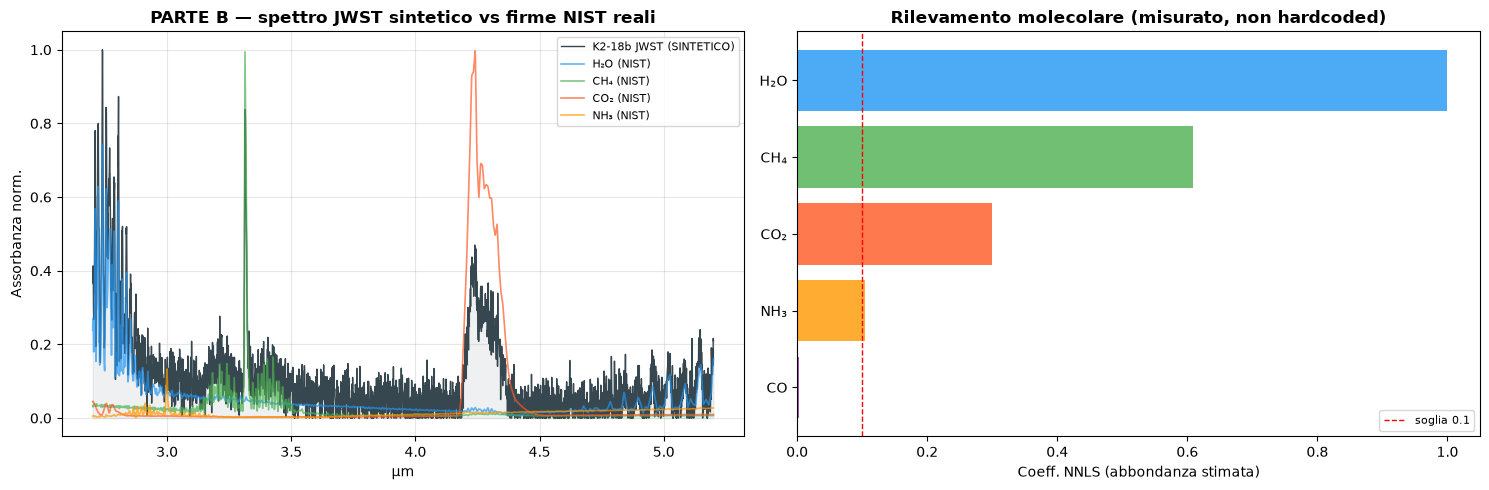

In [10]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
ax=axes[0]
ax.plot(wl_jwst,synth,color='#37474F',lw=1,label='K2-18b JWST (SINTETICO)')
ax.fill_between(wl_jwst,0,synth,color='#37474F',alpha=0.08)
for n in names:
    if n in detected:
        ax.plot(wl_jwst,grid[n],color=COLORS[n],lw=1.2,alpha=0.7,label=f'{LABELS[n]} (NIST)')
ax.set_title('PARTE B — spettro JWST sintetico vs firme NIST reali',fontsize=12,fontweight='bold')
ax.set_xlabel('µm'); ax.set_ylabel('Assorbanza norm.'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax=axes[1]
bars=ax.barh([LABELS[n] for n in dfB['nome']], dfB['Coeff. NNLS'],
             color=[COLORS[n] for n in dfB['nome']], alpha=0.8)
ax.axvline(THRESH,color='red',ls='--',lw=1,label=f'soglia {THRESH}')
ax.set_xlabel('Coeff. NNLS (abbondanza stimata)')
ax.set_title('Rilevamento molecolare (misurato, non hardcoded)',fontsize=12,fontweight='bold')
ax.legend(fontsize=8); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Conclusioni

**Parte A (dati REALI):** lo spettro HST/WFC3 di K2-18b mostra un
assorbimento nella banda dell'acqua a ~1.4 µm. Il fit NNLS lo quantifica *dai
dati* (coefficiente H₂O > 0, con un forte miglioramento del fit rispetto a uno
spettro piatto). È il risultato storico su cui K2-18b divenne famoso (Benneke
et al. 2019, Tsiaras et al. 2019): **vapore acqueo** nell'atmosfera.

**Parte B (demo JWST sintetica):** nel range 2.7–5 µm il metodo NNLS con
**firme NIST reali** ritrova H₂O, CH₄ e CO₂ — le molecole che JWST ha
effettivamente rilevato in K2-18b (Madhusudhan et al. 2023, insieme alla
discussa e non confermata possibile firma di DMS).

> **Insegnamento — attenzione ai falsi positivi.** Rieseguendo la Parte B
> capita che NNLS assegni un piccolo coefficiente anche a **NH₃**, che *non* è
> nella miscela. Non è un errore del codice: NH₃ ha bande che si **sovrappongono**
> a quelle di H₂O e CH₄ nell'IR medio, quindi un po' del suo profilo aiuta a
> "spiegare" lo spettro. È esattamente il problema della **degenerazione
> spettrale** nella spettroscopia esoplanetaria reale: per questo servono
> significatività statistica, dati a più alta risoluzione e retrieval bayesiani,
> non un singolo coefficiente sopra soglia. Guarda l'*ampiezza* dei coefficienti:
> H₂O/CH₄/CO₂ dominano, NH₃ resta marginale.

**Onestà scientifica del notebook:**
- Parte A = **dati misurati** (HST), rilevamento **calcolato**.
- Parte B = **spettro simulato** (etichettato), ma **firme reali** e metodo reale.
- Nessuna colonna "rilevata" scritta a mano: tutto passa da NNLS.

**Limiti:** i dati JWST NIRSpec ad alta risoluzione di K2-18b non sono nel NASA
Archive in forma tabulata; per un'analisi reale servono i prodotti JWST (MAST)
e modelli di trasferimento radiativo (petitRADTRANS, TauREx).